# Exploring CMIP6 Climate Model Data

This notebook introduces the Coupled Model Intercomparison Project Phase 6 (CMIP6) archive using cloud-based data catalogs and the intake-esm Python package.

The goal is to:
- Connect to an open CMIP6 catalog.
- Explore the structure of available datasets.
- Learn how to query model metadata programmatically.
- Prepare for more detailed analysis (such as the temperature study in the companion notebook).

In [1]:
import intake
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# What is CMIP6?

The Coupled Model Intercomparison Project Phase 6 (CMIP6) is an international collaboration that provides standardized climate model simulations for research and assessment (e.g., IPCC AR6).

Each dataset in CMIP6 represents simulations from different modeling centers around the world, spanning historical and future climate scenarios.

We can access these datasets directly from the cloud using the intake-esm catalog — avoiding the need to download multi-terabyte files locally.

In [2]:
for url in [
    "https://cmip6.storage.googleapis.com/pangeo-cmip6.json",  # preferred source
    "https://raw.githubusercontent.com/NCAR/intake-esm-datastore/master/catalogs/sample-cmip6.json",  # fallback
]:
    try:
        col = intake.open_esm_datastore(url)
        print(f"Successfully opened catalog from:\n{url}")
        break
    except Exception as e:
        print(f"Failed to open {url}\n   {e}")

Successfully opened catalog from:
https://cmip6.storage.googleapis.com/pangeo-cmip6.json


# Exploring the Catalog

The catalog provides metadata for thousands of CMIP6 datasets.
Each entry includes:
- source_id: The model name (e.g., MPI-ESM1-2-LR)
- experiment_id: The scenario or simulation (e.g., historical, SSP5-8.5)
- variable_id: The variable measured (e.g., tas, pr, psl)
- table_id: Frequency of output (e.g., monthly Amon)
- member_id: Model ensemble member

Let’s inspect the structure of this catalog.

In [3]:
# Display catalog structure
print("Catalog metadata fields:", list(col.df.columns))
print(f"\nNumber of datasets in catalog: {len(col.df)}")
col.df.head(5)

Catalog metadata fields: ['activity_id', 'institution_id', 'source_id', 'experiment_id', 'member_id', 'table_id', 'variable_id', 'grid_label', 'zstore', 'dcpp_init_year', 'version']

Number of datasets in catalog: 514818


,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,<NA>,20170706


# Summarizing Available Models and Variables

We can quickly summarize the catalog by counting unique models and variables to understand its scope.

In [4]:
# Count available models and variables
n_models = col.df['source_id'].nunique()
n_vars = col.df['variable_id'].nunique()

print(f"Total models available: {n_models}")
print(f"Total variables available: {n_vars}")

# Display top 10 most common variables
col.df['variable_id'].value_counts().head(10)


Total models available: 88
Total variables available: 700


variable_id
tas        17447
psl        14310
clt        12397
ps         11988
evspsbl    11014
ts         10474
tos        10278
huss        9482
sos         8687
pr          8639
Name: count, dtype: int64[pyarrow]

# Searching the Catalog

The catalog can be queried to return only datasets of interest - for example, all surface air temperature (tas) records from historical experiments.

In [5]:
query = dict(
    experiment_id=['historical'],
    variable_id=['tas'],
    table_id=['Amon']
)

subset = col.search(**query)
subset.df.head(10)

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r3i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,<NA>,20180701
1,CMIP,NOAA-GFDL,GFDL-ESM4,historical,r2i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-ESM4/hist...,<NA>,20180701
2,CMIP,NOAA-GFDL,GFDL-CM4,historical,r1i1p1f1,Amon,tas,gr1,gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/histo...,<NA>,20180701
3,CMIP,IPSL,IPSL-CM6A-LR,historical,r8i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
4,CMIP,IPSL,IPSL-CM6A-LR,historical,r2i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
5,CMIP,IPSL,IPSL-CM6A-LR,historical,r30i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
6,CMIP,IPSL,IPSL-CM6A-LR,historical,r29i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
7,CMIP,IPSL,IPSL-CM6A-LR,historical,r3i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
8,CMIP,IPSL,IPSL-CM6A-LR,historical,r6i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803
9,CMIP,IPSL,IPSL-CM6A-LR,historical,r27i1p1f1,Amon,tas,gr,gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/histor...,<NA>,20180803


# Understanding Model Metadata

Each dataset is uniquely defined by its source model, experiment, and data frequency.
We can check how many different models provide monthly tas data in the historical experiment.

In [6]:
unique_models = subset.df['source_id'].unique()
print(f"Number of models providing monthly tas data: {len(unique_models)}")
print(unique_models[:10])  # show first 10

Number of models providing monthly tas data: 64
<ArrowExtensionArray>
[   'GFDL-ESM4',     'GFDL-CM4', 'IPSL-CM6A-LR',  'GISS-E2-1-G',
   'CNRM-CM6-1',  'BCC-CSM2-MR',  'CNRM-ESM2-1',       'MIROC6',
     'BCC-ESM1',   'MRI-ESM2-0']
Length: 10, dtype: large_string[pyarrow]


# Visualizing Model Distribution

Let’s visualize how many datasets are available per model to see which centers have the largest CMIP6 presence.

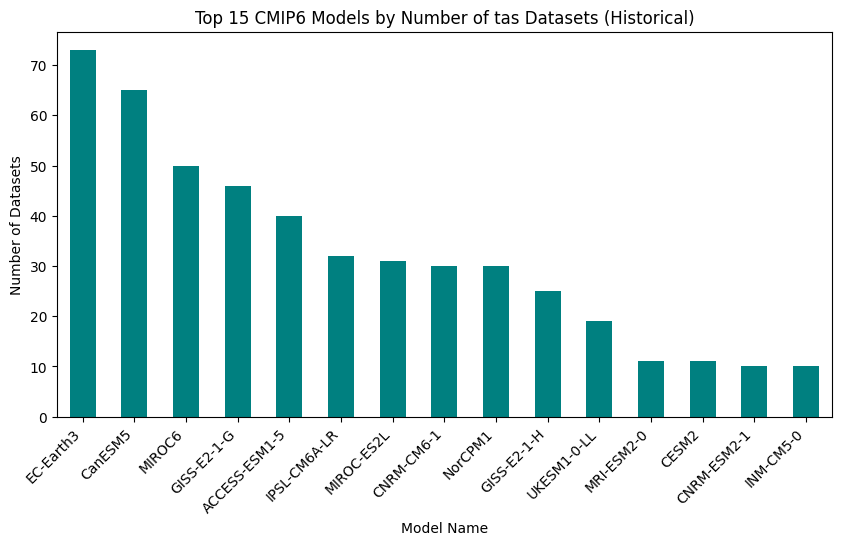

In [7]:
model_counts = subset.df['source_id'].value_counts().head(15)

plt.figure(figsize=(10,5))
model_counts.plot(kind='bar', color='teal')
plt.title("Top 15 CMIP6 Models by Number of tas Datasets (Historical)")
plt.ylabel("Number of Datasets")
plt.xlabel("Model Name")
plt.xticks(rotation=45, ha='right')
plt.show()

# Preparing for Further Analysis

Now that we’ve explored the structure of the CMIP6 catalog and filtered for a specific variable (tas), we can proceed to download or connect directly to one model’s data for detailed analysis.

In the next notebook - Exploring CMIP6 Surface Temperature - we’ll:
- Open one dataset from the subset (e.g., MPI-ESM1-2-LR)
- Convert it to a manageable xarray.Dataset
- Visualize temperature patterns on global maps and zonal means

# Summary

This notebook provided an overview of how to:
- Access the CMIP6 catalog via intake-esm
- Explore its metadata fields and structure
- Query specific experiments and variables
- Identify which models provide the desired data

By connecting to cloud-hosted catalogs, we bypass the need for local downloads and create reproducible, scalable workflows that align with modern open-science principles.